In [81]:
# plotting the results of the benchmark 
import matplotlib.pyplot as plt
import numpy as np
import glob
import pandas as pd
import seaborn as sns
from matplotlib.ticker import LogLocator
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from math import pi
from bs4 import BeautifulSoup
import os

# replicate indices 
replicate_indices = [str(i).zfill(2) for i in range(1, 31)]
res_base_path = "/mnt/ssd/performance_benchmark"


## Benachmark results

### Dataframe generation 

This extracts the runtime and resource usage for the 30 replicate runs and constructs a data frame saved to csv. The code should be only run once, after the benchmark run is completed.

In [2]:
# initiating empty lists to store the values
# --- matlab ---
matlab_intensity_realtime_values = []
matlab_intensity_peak_rss_values = []
matlab_intensity_rchar_values = []
matlab_intensity_wchar_values = []
matlab_intensity_read_bytes_values = []
matlab_intensity_write_bytes_values = []
matlab_intensity_pmem_values = []
matlab_intensity_pcpu_values = []
matlab_intensity_peak_vmem_values = []


matlab_alignment_realtime_values = []
matlab_alignment_peak_rss_values = []
matlab_alignment_rchar_values = []
matlab_alignment_wchar_values = []
matlab_alignment_read_bytes_values = []
matlab_alignment_write_bytes_values = []
matlab_alignment_pmem_values = []
matlab_alignment_pcpu_values = []
matlab_alignment_peak_vmem_values = []

matlab_stitching_realtime_values = []
matlab_stitching_peak_rss_values = []
matlab_stitching_rchar_values = []
matlab_stitching_wchar_values = []
matlab_stitching_read_bytes_values = []
matlab_stitching_write_bytes_values = []
matlab_stitching_pmem_values = []
matlab_stitching_pcpu_values = []
matlab_stitching_peak_vmem_values = []

matlab_count_realtime_values = []
matlab_count_peak_rss_values = []
matlab_count_rchar_values = []
matlab_count_wchar_values = []
matlab_count_read_bytes_values = []
matlab_count_write_bytes_values = []
matlab_count_pmem_values = []
matlab_count_pcpu_values = []
matlab_count_peak_vmem_values = []

# --- nextflow ---
nextflow_intensity_realtime_values = []
nextflow_intensity_peak_rss_values = []
nextflow_intensity_rchar_values = []
nextflow_intensity_wchar_values = []
nextflow_intensity_read_bytes_values = []
nextflow_intensity_write_bytes_values = []
nextflow_intensity_pmem_values = []
nextflow_intensity_pcpu_values = []
nextflow_intensity_peak_vmem_values = []


nextflow_alignment_realtime_values = []
nextflow_alignment_peak_rss_values = []
nextflow_alignment_rchar_values = []
nextflow_alignment_wchar_values = []
nextflow_alignment_read_bytes_values = []
nextflow_alignment_write_bytes_values = []
nextflow_alignment_pmem_values = []
nextflow_alignment_pcpu_values = []
nextflow_alignment_peak_vmem_values = []


nextflow_stitching_realtime_values = []
nextflow_stitching_peak_rss_values = []
nextflow_stitching_rchar_values = []
nextflow_stitching_wchar_values = []
nextflow_stitching_read_bytes_values = []
nextflow_stitching_write_bytes_values = []
nextflow_stitching_pmem_values = []
nextflow_stitching_pcpu_values = []
nextflow_stitching_peak_vmem_values = []

nextflow_count_realtime_values = []
nextflow_count_peak_rss_values = []
nextflow_count_rchar_values = []
nextflow_count_wchar_values = []
nextflow_count_read_bytes_values = []
nextflow_count_write_bytes_values = []
nextflow_count_pmem_values = []
nextflow_count_pcpu_values = []
nextflow_count_peak_vmem_values = []


In [3]:
# aggregate data from matlab/replicate_[index]/process_intensity/ get the matlab_trace.log file and extract the realtime value.

#iterate over the list of strings for the index since they are 0 padded in the folder names
for i in replicate_indices:
    with open(f'{res_base_path}/matlab/replicate_{i}/process_intensity/matlab_trace.log', 'r') as f:
        for line in f:
            if 'realtime' in line:
                realtime_value = float(line.split('realtime=')[1].strip())
                matlab_intensity_realtime_values.append(realtime_value)
            if 'peak_rss' in line:
                peak_rss_value = float(line.split('peak_rss=')[1].strip())
                matlab_intensity_peak_rss_values.append(peak_rss_value)
            if 'rchar' in line:
                rchar_value = float(line.split('rchar=')[1].strip())
                matlab_intensity_rchar_values.append(rchar_value)
            if 'wchar' in line:
                wchar_value = float(line.split('wchar=')[1].strip())
                matlab_intensity_wchar_values.append(wchar_value)
            if 'read_bytes' in line:
                read_bytes_value = float(line.split('read_bytes=')[1].strip())
                matlab_intensity_read_bytes_values.append(read_bytes_value)
            if 'write_bytes' in line:
                write_bytes_value = float(line.split('write_bytes=')[1].strip())
                matlab_intensity_write_bytes_values.append(write_bytes_value)
            if '%mem' in line:
                mem_value = float(line.split('%mem=')[1].strip())
                matlab_intensity_pmem_values.append(mem_value)
            if '%cpu' in line:
                cpu_value = float(line.split('%cpu=')[1].strip())
                matlab_intensity_pcpu_values.append(cpu_value)
            if 'peak_vmem' in line:
                peak_vmem_value = float(line.split('peak_vmem=')[1].strip())
                matlab_intensity_peak_vmem_values.append(peak_vmem_value)
    with open(f'{res_base_path}/matlab/replicate_{i}/process_align/matlab_trace.log', 'r') as f:
        for line in f:
            if 'realtime' in line:
                realtime_value = float(line.split('realtime=')[1].strip())
                matlab_alignment_realtime_values.append(realtime_value)
            if 'peak_rss' in line:
                peak_rss_value = float(line.split('peak_rss=')[1].strip())
                matlab_alignment_peak_rss_values.append(peak_rss_value)
            if 'rchar' in line:
                rchar_value = float(line.split('rchar=')[1].strip())
                matlab_alignment_rchar_values.append(rchar_value)
            if 'wchar' in line:
                wchar_value = float(line.split('wchar=')[1].strip())
                matlab_alignment_wchar_values.append(wchar_value)
            if 'read_bytes' in line:
                read_bytes_value = float(line.split('read_bytes=')[1].strip())
                matlab_alignment_read_bytes_values.append(read_bytes_value)
            if 'write_bytes' in line:
                write_bytes_value = float(line.split('write_bytes=')[1].strip())
                matlab_alignment_write_bytes_values.append(write_bytes_value)
            if '%mem' in line:
                mem_value = float(line.split('%mem=')[1].strip())
                matlab_alignment_pmem_values.append(mem_value)
            if '%cpu' in line:
                cpu_value = float(line.split('%cpu=')[1].strip())
                matlab_alignment_pcpu_values.append(cpu_value)
            if 'peak_vmem' in line:
                peak_vmem_value = float(line.split('peak_vmem=')[1].strip())
                matlab_alignment_peak_vmem_values.append(peak_vmem_value)
    with open(f'{res_base_path}/matlab/replicate_{i}/process_stitch/matlab_trace.log', 'r') as f:
        for line in f:
            if 'realtime' in line:
                realtime_value = float(line.split('realtime=')[1].strip())
                matlab_stitching_realtime_values.append(realtime_value)
            if 'peak_rss' in line:
                peak_rss_value = float(line.split('peak_rss=')[1].strip())
                matlab_stitching_peak_rss_values.append(peak_rss_value)
            if 'rchar' in line:
                rchar_value = float(line.split('rchar=')[1].strip())
                matlab_stitching_rchar_values.append(rchar_value)
            if 'wchar' in line:
                wchar_value = float(line.split('wchar=')[1].strip())
                matlab_stitching_wchar_values.append(wchar_value)
            if 'read_bytes' in line:
                read_bytes_value = float(line.split('read_bytes=')[1].strip())
                matlab_stitching_read_bytes_values.append(read_bytes_value)
            if 'write_bytes' in line:
                write_bytes_value = float(line.split('write_bytes=')[1].strip())
                matlab_stitching_write_bytes_values.append(write_bytes_value)
            if '%mem' in line:
                mem_value = float(line.split('%mem=')[1].strip())
                matlab_stitching_pmem_values.append(mem_value)
            if '%cpu' in line:
                cpu_value = float(line.split('%cpu=')[1].strip())
                matlab_stitching_pcpu_values.append(cpu_value)
            if 'peak_vmem' in line:
                peak_vmem_value = float(line.split('peak_vmem=')[1].strip())
                matlab_stitching_peak_vmem_values.append(peak_vmem_value)
    with open(f'{res_base_path}/matlab/replicate_{i}/process_count/matlab_trace.log', 'r') as f:
        for line in f:
            if 'realtime' in line:
                realtime_value = float(line.split('realtime=')[1].strip())
                matlab_count_realtime_values.append(realtime_value)
            if 'peak_rss' in line:
                peak_rss_value = float(line.split('peak_rss=')[1].strip())
                matlab_count_peak_rss_values.append(peak_rss_value)
            if 'rchar' in line:
                rchar_value = float(line.split('rchar=')[1].strip())
                matlab_count_rchar_values.append(rchar_value)
            if 'wchar' in line:
                wchar_value = float(line.split('wchar=')[1].strip())
                matlab_count_wchar_values.append(wchar_value)
            if 'read_bytes' in line:
                read_bytes_value = float(line.split('read_bytes=')[1].strip())
                matlab_count_read_bytes_values.append(read_bytes_value)
            if 'write_bytes' in line:
                write_bytes_value = float(line.split('write_bytes=')[1].strip())
                matlab_count_write_bytes_values.append(write_bytes_value)
            if '%mem' in line:
                mem_value = float(line.split('%mem=')[1].strip())
                matlab_count_pmem_values.append(mem_value)
            if '%cpu' in line:
                cpu_value = float(line.split('%cpu=')[1].strip())
                matlab_count_pcpu_values.append(cpu_value)
            if 'peak_vmem' in line:
                peak_vmem_value = float(line.split('peak_vmem=')[1].strip())
                matlab_count_peak_vmem_values.append(peak_vmem_value)

In [4]:
# from the value arrays create a pandas datafram with the following columns: 
# process; realtime; peak_rss; software
# and the values in the process column should be 'intensity', 'alignment', 'stitching', 'count'
# the software column should be 'matlab' for the matlab values and 'nextflow' for the nextflow values

matlab_df = pd.DataFrame({
    'process': ['intensity'] * len(matlab_intensity_realtime_values) +
               ['alignment'] * len(matlab_alignment_realtime_values) +
               ['stitching'] * len(matlab_stitching_realtime_values) +
               ['count'] * len(matlab_count_realtime_values),
    'realtime': matlab_intensity_realtime_values +
                matlab_alignment_realtime_values +
                matlab_stitching_realtime_values +
                matlab_count_realtime_values,
    'peak_rss': matlab_intensity_peak_rss_values +
                matlab_alignment_peak_rss_values +
                matlab_stitching_peak_rss_values +
                matlab_count_peak_rss_values,
    'rchar': matlab_intensity_rchar_values +
             matlab_alignment_rchar_values +
             matlab_stitching_rchar_values +
             matlab_count_rchar_values,
    'wchar': matlab_intensity_wchar_values +
             matlab_alignment_wchar_values +
             matlab_stitching_wchar_values +
             matlab_count_wchar_values,
    'read_bytes': matlab_intensity_read_bytes_values +
                  matlab_alignment_read_bytes_values +
                  matlab_stitching_read_bytes_values +
                  matlab_count_read_bytes_values,
    'write_bytes': matlab_intensity_write_bytes_values +
                   matlab_alignment_write_bytes_values +
                   matlab_stitching_write_bytes_values +
                   matlab_count_write_bytes_values,
    'pmem': matlab_intensity_pmem_values +
            matlab_alignment_pmem_values +
            matlab_stitching_pmem_values +
            matlab_count_pmem_values,
    'pcpu': matlab_intensity_pcpu_values +
            matlab_alignment_pcpu_values +
            matlab_stitching_pcpu_values +
            matlab_count_pcpu_values,
     'peak_vmem': matlab_intensity_peak_vmem_values +
                   matlab_alignment_peak_vmem_values +
                   matlab_stitching_peak_vmem_values +
                   matlab_count_peak_vmem_values,
    'software': ['matlab'] * (len(matlab_intensity_realtime_values) +
                             len(matlab_alignment_realtime_values) +
                             len(matlab_stitching_realtime_values) +
                             len(matlab_count_realtime_values))
})



In [5]:
matlab_df

,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,peak_vmem,software
0,intensity,33778.0,1667984.0,97878617.0,183114842.0,4096.0,183414784.0,25.0,1792.0,10310436.0,matlab
1,intensity,33513.0,1612204.0,98389069.0,183114840.0,36864.0,183418880.0,24.0,1828.0,10268932.0,matlab
2,intensity,33068.0,1593196.0,97881273.0,183114840.0,4096.0,183414784.0,24.0,1845.0,10268928.0,matlab
3,intensity,33053.0,1591360.0,98389093.0,183114842.0,8192.0,183414784.0,24.0,1833.0,10203396.0,matlab
4,intensity,33579.0,1603700.0,98389120.0,183114851.0,4546560.0,183414784.0,24.0,1825.0,10338568.0,matlab
...,...,...,...,...,...,...,...,...,...,...,...
115,count,150358.0,10890520.0,65284587.0,2190309.0,0.0,2588672.0,166.0,45.0,53731488.0,matlab
116,count,153879.0,10880220.0,65295162.0,2190304.0,0.0,2596864.0,166.0,44.0,53821884.0,matlab
117,count,151933.0,10866140.0,65295992.0,2190300.0,0.0,2580480.0,166.0,44.0,54156736.0,matlab
118,count,148898.0,10876100.0,67374355.0,2190309.0,0.0,2572288.0,166.0,46.0,53647372.0,matlab


In [6]:
# get the data from the work dir -- correct values --- 
# create df with columns: process; hash/id
nextflow_id_df = pd.DataFrame(columns=['replicate','process', 'hash/id'])
# fill the df with the values from the files by iterating over the replicates and processes
for i in replicate_indices:
    file_pattern = f'{res_base_path}/nextflow/replicate_{i}/pipeline_info/execution_trace_*.txt'
    file_list = glob.glob(file_pattern)
    if file_list:
        df = pd.read_csv(file_list[0], sep='\t')
        # Create rows to add
        rows_to_add = [
            {'replicate': i, 'process': 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPH_INTENSITY (TEST1)', 
             'hash/id': df[df['name'] == 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPH_INTENSITY (TEST1)']['hash'].values[0]},
            {'replicate': i, 'process': 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHALIGN (TEST1)', 
             'hash/id': df[df['name'] == 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHALIGN (TEST1)']['hash'].values[0]},
            {'replicate': i, 'process': 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHSTITCH (TEST1)', 
             'hash/id': df[df['name'] == 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHSTITCH (TEST1)']['hash'].values[0]},
            {'replicate': i, 'process': 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1)', 
             'hash/id': df[df['name'] == 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1)']['hash'].values[0]}
        ]
        
        # Use pd.concat to add rows
        nextflow_id_df = pd.concat([nextflow_id_df, pd.DataFrame(rows_to_add)], ignore_index=True)

In [7]:
nextflow_id_df

# adding two new empty columns to the dataframe 
nextflow_id_df['realtime'] = np.nan
nextflow_id_df['peak_rss'] = np.nan
nextflow_id_df['rchar'] = np.nan
nextflow_id_df['wchar'] = np.nan
nextflow_id_df['read_bytes'] = np.nan
nextflow_id_df['write_bytes'] = np.nan
nextflow_id_df['pmem'] = np.nan
nextflow_id_df['pcpu'] = np.nan
nextflow_id_df['peak_vmem'] = np.nan


In [8]:
# now iterating over the  rows in the dataframe, getting into the work dir and from the hash in the dataframe into the right sub dir to finde there the trace file and add real time and peak rss to the dataframe for the specific hash 
for index, row in nextflow_id_df.iterrows():
    replicate = row['replicate']
    process = row['process']
    hash_id = row['hash/id']
    
    # Construct the path to the trace file with glob pattern to find the trace file in the right subdir
    trace_file_pattern = f'{res_base_path}/nextflow/replicate_{replicate}/work/{hash_id}*/.command.trace'
    trace_file_path = glob.glob(trace_file_pattern)
    if trace_file_path:
        with open(trace_file_path[0], 'r') as f:
            for line in f:
                if 'realtime' in line:
                    realtime_value = float(line.split('realtime=')[1].strip())
                    # get the row with the current replicate and add the realtime value to the realtime column
                    nextflow_id_df.at[index, 'realtime'] = realtime_value
                if 'peak_rss' in line:
                    peak_rss_value = float(line.split('peak_rss=')[1].strip())
                    nextflow_id_df.at[index, 'peak_rss'] = peak_rss_value
                if 'rchar' in line:
                    rchar_value = float(line.split('rchar=')[1].strip())
                    nextflow_id_df.at[index, 'rchar'] = rchar_value
                if 'wchar' in line:
                    wchar_value = float(line.split('wchar=')[1].strip())
                    nextflow_id_df.at[index, 'wchar'] = wchar_value
                if 'read_bytes' in line:
                    read_bytes_value = float(line.split('read_bytes=')[1].strip())
                    nextflow_id_df.at[index, 'read_bytes'] = read_bytes_value
                if 'write_bytes' in line:
                    write_bytes_value = float(line.split('write_bytes=')[1].strip())
                    nextflow_id_df.at[index, 'write_bytes'] = write_bytes_value
                if '%mem' in line:
                    mem_value = float(line.split('%mem=')[1].strip())
                    nextflow_id_df.at[index, 'pmem'] = mem_value
                if '%cpu' in line:
                    cpu_value = float(line.split('%cpu=')[1].strip())
                    nextflow_id_df.at[index, 'pcpu'] = cpu_value
                if 'peak_vmem' in line:
                    peak_vmem_value = float(line.split('peak_vmem=')[1].strip())
                    nextflow_id_df.at[index, 'peak_vmem'] = peak_vmem_value


In [9]:
nextflow_id_df

,replicate,process,hash/id,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,peak_vmem
0,01,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,d5/d6599e,34976.0,1464480.0,266489280.0,3.121421e+08,4096.0,3.174318e+08,22.0,1794.0,9395924.0
1,01,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,1b/48d7c2,90210.0,1510260.0,355079662.0,1.949282e+08,0.0,2.002412e+08,22.0,5745.0,9630508.0
2,01,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,b1/bf5b29,80680.0,1875168.0,352818674.0,1.215115e+09,49152.0,1.220555e+09,24.0,1406.0,9728572.0
3,01,NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1),f6/0b776a,97298.0,15031388.0,473450475.0,1.945338e+06,0.0,1.892352e+06,229.0,1075.0,53881252.0
4,02,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,1b/c8e648,34977.0,1481896.0,266513785.0,3.121421e+08,225280.0,3.174318e+08,22.0,1787.0,9337784.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,29,NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1),fc/b09b1c,97462.0,15056480.0,473450527.0,1.945336e+06,0.0,1.892352e+06,229.0,1074.0,53912292.0
116,30,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,e6/ad7fb2,34782.0,1510148.0,266504958.0,3.121421e+08,229376.0,3.174318e+08,23.0,1788.0,9363120.0
117,30,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,e0/e4fb24,89902.0,1560672.0,354588194.0,1.949282e+08,0.0,2.002412e+08,22.0,5762.0,10292552.0
118,30,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,8d/156a72,81458.0,1879108.0,350732084.0,1.215116e+09,49152.0,1.220555e+09,24.0,1408.0,10074164.0


In [10]:
# replace the process names to be matched with the matlab df process names
nextflow_id_df['process'] = nextflow_id_df['process'].replace({
    'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPH_INTENSITY (TEST1)': 'intensity',
    'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHALIGN (TEST1)': 'alignment',
    'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHSTITCH (TEST1)': 'stitching',
    'NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1)': 'count'
})  



In [11]:
# combine both dataframe and write them to csv. 
# first drop hash column from nextflow_id_df
nextflow_id_df = nextflow_id_df.drop(columns=['hash/id'])
# add software column to nextflow_id_df with value 'nextflow'
nextflow_id_df['software'] = 'nextflow'
# concatenate the two dataframes
combined_df = pd.concat([matlab_df, nextflow_id_df], ignore_index=True)
# write the combined dataframe to csv
combined_df.to_csv(f'{res_base_path}/benchmark_results.csv', index=False)    


In [ ]:
# Combinde dataframe for nf-core7lsmquant results and numorph results for resource usage comparison. Raw data 
combined_df


,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,peak_vmem,software,replicate
0,intensity,33778.0,1667984.0,97878617.0,1.831148e+08,4096.0,1.834148e+08,25.0,1792.0,10310436.0,matlab,NaN
1,intensity,33513.0,1612204.0,98389069.0,1.831148e+08,36864.0,1.834189e+08,24.0,1828.0,10268932.0,matlab,NaN
2,intensity,33068.0,1593196.0,97881273.0,1.831148e+08,4096.0,1.834148e+08,24.0,1845.0,10268928.0,matlab,NaN
3,intensity,33053.0,1591360.0,98389093.0,1.831148e+08,8192.0,1.834148e+08,24.0,1833.0,10203396.0,matlab,NaN
4,intensity,33579.0,1603700.0,98389120.0,1.831149e+08,4546560.0,1.834148e+08,24.0,1825.0,10338568.0,matlab,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
235,count,97462.0,15056480.0,473450527.0,1.945336e+06,0.0,1.892352e+06,229.0,1074.0,53912292.0,nextflow,29
236,intensity,34782.0,1510148.0,266504958.0,3.121421e+08,229376.0,3.174318e+08,23.0,1788.0,9363120.0,nextflow,30
237,alignment,89902.0,1560672.0,354588194.0,1.949282e+08,0.0,2.002412e+08,22.0,5762.0,10292552.0,nextflow,30
238,stitching,81458.0,1879108.0,350732084.0,1.215116e+09,49152.0,1.220555e+09,24.0,1408.0,10074164.0,nextflow,30


### Load benchmark data
The following code is to read in the benchmark data (benchmark_results.csv) and convert the raw units into human readable/ relatable units

In [82]:
#read in the saved combined dataframe from csv . 
raw_benchmark_df = pd.read_csv(f'{res_base_path}/benchmark_results.csv')
raw_benchmark_df

,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,peak_vmem,software,replicate
0,intensity,33778.0,1667984.0,97878617.0,1.831148e+08,4096.0,1.834148e+08,25.0,1792.0,10310436.0,matlab,NaN
1,intensity,33513.0,1612204.0,98389069.0,1.831148e+08,36864.0,1.834189e+08,24.0,1828.0,10268932.0,matlab,NaN
2,intensity,33068.0,1593196.0,97881273.0,1.831148e+08,4096.0,1.834148e+08,24.0,1845.0,10268928.0,matlab,NaN
3,intensity,33053.0,1591360.0,98389093.0,1.831148e+08,8192.0,1.834148e+08,24.0,1833.0,10203396.0,matlab,NaN
4,intensity,33579.0,1603700.0,98389120.0,1.831149e+08,4546560.0,1.834148e+08,24.0,1825.0,10338568.0,matlab,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
235,count,97462.0,15056480.0,473450527.0,1.945336e+06,0.0,1.892352e+06,229.0,1074.0,53912292.0,nextflow,29.0
236,intensity,34782.0,1510148.0,266504958.0,3.121421e+08,229376.0,3.174318e+08,23.0,1788.0,9363120.0,nextflow,30.0
237,alignment,89902.0,1560672.0,354588194.0,1.949282e+08,0.0,2.002412e+08,22.0,5762.0,10292552.0,nextflow,30.0
238,stitching,81458.0,1879108.0,350732084.0,1.215116e+09,49152.0,1.220555e+09,24.0,1408.0,10074164.0,nextflow,30.0


In [83]:
# convert raw data units into more human readable units.
benchmark_df = raw_benchmark_df.copy()
benchmark_df['realtime'] = benchmark_df['realtime'] / 60000
benchmark_df['peak_rss'] = benchmark_df['peak_rss'] / (1024 * 1024) # GiB --> raw in KiB
benchmark_df['read_bytes'] = benchmark_df['read_bytes'] / (1024 ) # KiB --> raw in bytes
benchmark_df['write_bytes'] = benchmark_df['write_bytes'] / (1024 * 1024 * 1024) # GiB --> raw in bytes
benchmark_df['pcpu'] = benchmark_df['pcpu'] / 10
benchmark_df['pmem'] = benchmark_df['pmem'] / 10
benchmark_df['rchar'] = benchmark_df['rchar'] 
benchmark_df['wchar'] = benchmark_df['wchar']
benchmark_df['peak_vmem'] = benchmark_df['peak_vmem'] / (1024 * 1024) # GiB --> raw in KiB
benchmark_df

,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,peak_vmem,software,replicate
0,intensity,0.562967,1.590714,97878617.0,1.831148e+08,4.0,0.170818,2.5,179.2,9.832798,matlab,NaN
1,intensity,0.558550,1.537518,98389069.0,1.831148e+08,36.0,0.170822,2.4,182.8,9.793217,matlab,NaN
2,intensity,0.551133,1.519390,97881273.0,1.831148e+08,4.0,0.170818,2.4,184.5,9.793213,matlab,NaN
3,intensity,0.550883,1.517639,98389093.0,1.831148e+08,8.0,0.170818,2.4,183.3,9.730717,matlab,NaN
4,intensity,0.559650,1.529408,98389120.0,1.831149e+08,4440.0,0.170818,2.4,182.5,9.859627,matlab,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
235,count,1.624367,14.358978,473450527.0,1.945336e+06,0.0,0.001762,22.9,107.4,51.414768,nextflow,29.0
236,intensity,0.579700,1.440189,266504958.0,3.121421e+08,224.0,0.295631,2.3,178.8,8.929367,nextflow,30.0
237,alignment,1.498367,1.488373,354588194.0,1.949282e+08,0.0,0.186489,2.2,576.2,9.815742,nextflow,30.0
238,stitching,1.357633,1.792057,350732084.0,1.215116e+09,48.0,1.136730,2.4,140.8,9.607471,nextflow,30.0


In [84]:
# rename software
#summary_stats = benchmark_df.groupby(['software', 'process']).agg({'realtime': ['mean', 'std'], 'peak_rss': ['mean', 'std'], 'read_bytes': ['mean', 'std'], 'write_bytes': ['mean', 'std'], 'pcpu': ['mean', 'std'], 'pmem': ['mean', 'std']})
benchmark_df = benchmark_df.assign(software=benchmark_df['software'].replace({'matlab': 'NuMorph', 'nextflow': 'nf-core/lsmquant'}))
benchmark_df = benchmark_df.assign(software=benchmark_df['software'].replace({'matlab': 'NuMorph', 'nextflow': 'nf-core/lsmquant'}))
benchmark_df


,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,peak_vmem,software,replicate
0,intensity,0.562967,1.590714,97878617.0,1.831148e+08,4.0,0.170818,2.5,179.2,9.832798,NuMorph,NaN
1,intensity,0.558550,1.537518,98389069.0,1.831148e+08,36.0,0.170822,2.4,182.8,9.793217,NuMorph,NaN
2,intensity,0.551133,1.519390,97881273.0,1.831148e+08,4.0,0.170818,2.4,184.5,9.793213,NuMorph,NaN
3,intensity,0.550883,1.517639,98389093.0,1.831148e+08,8.0,0.170818,2.4,183.3,9.730717,NuMorph,NaN
4,intensity,0.559650,1.529408,98389120.0,1.831149e+08,4440.0,0.170818,2.4,182.5,9.859627,NuMorph,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
235,count,1.624367,14.358978,473450527.0,1.945336e+06,0.0,0.001762,22.9,107.4,51.414768,nf-core/lsmquant,29.0
236,intensity,0.579700,1.440189,266504958.0,3.121421e+08,224.0,0.295631,2.3,178.8,8.929367,nf-core/lsmquant,30.0
237,alignment,1.498367,1.488373,354588194.0,1.949282e+08,0.0,0.186489,2.2,576.2,9.815742,nf-core/lsmquant,30.0
238,stitching,1.357633,1.792057,350732084.0,1.215116e+09,48.0,1.136730,2.4,140.8,9.607471,nf-core/lsmquant,30.0


##### Summary statistics

In [ ]:
# get the summary statistics for the benchmark df
summary_stats = benchmark_df.groupby(['software', 'process']).agg({'realtime': ['mean', 'std'], 'peak_rss': ['mean', 'std'], 'read_bytes': ['mean', 'std'], 'write_bytes': ['mean', 'std'], 'pcpu': ['mean', 'std'], 'pmem': ['mean', 'std'], 'rchar': ['mean', 'std'], 'wchar': ['mean', 'std'], 'peak_vmem': ['mean', 'std']})

print(summary_stats)

# write summary stats to csv
summary_stats.to_json('.results/benchmark-summary_stats.json', orient='index')

                            realtime             peak_rss            \
                                mean       std       mean       std   
software         process                                              
NuMorph          alignment  1.441050  0.016618   1.461342  0.071865   
                 count      2.506896  0.036267  10.375955  0.017919   
                 intensity  0.559451  0.008252   1.548400  0.031593   
                 stitching  1.285763  0.013750   1.778298  0.062061   
nf-core/lsmquant alignment  1.498782  0.014312   1.478917  0.021540   
                 count      1.633781  0.008800  14.359442  0.016511   
                 intensity  0.580183  0.005282   1.428336  0.028344   
                 stitching  1.356384  0.015579   1.750541  0.034829   

                            read_bytes             write_bytes                \
                                  mean         std        mean           std   
software         process                                  

### Plotting resource usage results

In [86]:
## color style for the plots
palette = {
    "NuMorph": "#a6cee3",
    "nf-core/lsmquant": "#4daf4a"
}

#### Barplots for all tracked resources: Supplementary figure ? 
The below code generates supplementary figure x

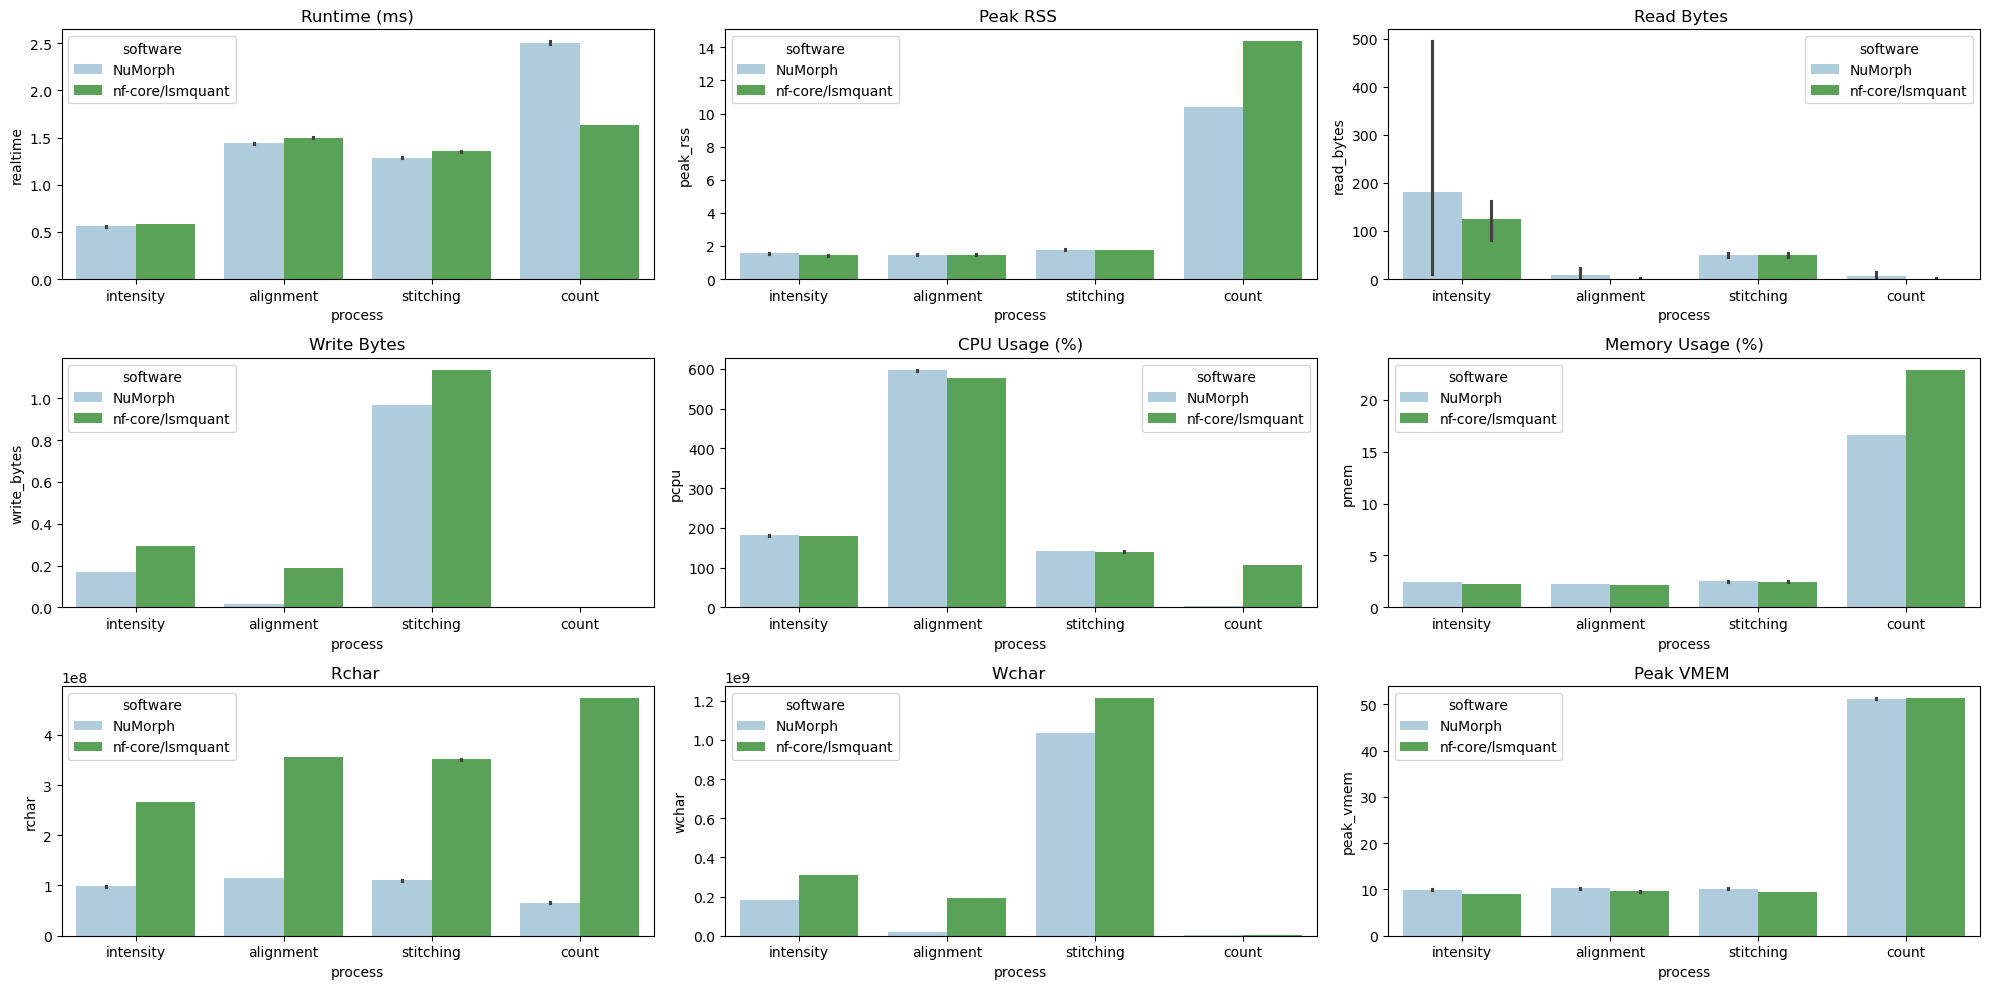

In [18]:
# barplots for all resources 
fig, axs = plt.subplots(3, 3, figsize=(20, 10))
sns.barplot(data=benchmark_df, x='process', y='realtime', hue='software', ax=axs[0, 0], palette=palette)
sns.barplot(data=benchmark_df, x='process', y='peak_rss', hue='software', ax=axs[0, 1], palette=palette)
sns.barplot(data=benchmark_df, x='process', y='read_bytes', hue='software', ax=axs[0, 2], palette=palette)
sns.barplot(data=benchmark_df, x='process', y='write_bytes', hue='software', ax=axs[1, 0], palette=palette)
sns.barplot(data=benchmark_df, x='process', y='pcpu', hue='software', ax=axs[1, 1], palette=palette)
sns.barplot(data=benchmark_df, x='process', y='pmem', hue='software', ax=axs[1, 2], palette=palette)
sns.barplot(data=benchmark_df, x='process', y='rchar', hue='software', ax=axs[2, 0], palette=palette)
sns.barplot(data=benchmark_df, x='process', y='wchar', hue='software', ax=axs[2, 1], palette=palette)
sns.barplot(data=benchmark_df, x='process', y='peak_vmem', hue='software', ax=axs[2, 2], palette=palette)
axs[0, 0].set_title('Runtime (ms)')
axs[0, 1].set_title('Peak RSS ')
axs[0, 2].set_title('Read Bytes ')
axs[1, 0].set_title('Write Bytes')
axs[1, 1].set_title('CPU Usage (%)')
axs[1, 2].set_title('Memory Usage (%)')
axs[2, 0].set_title('Rchar ')
axs[2, 1].set_title('Wchar ')
axs[2, 2].set_title('Peak VMEM ')

plt.tight_layout()



#### Manuscript Figure 5: Barplots runtime and peak rss
The code below is used to generate figure 5 from the manuscript.

/tmp/ipykernel_2518436/3334384937.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(processes, fontsize=14, rotation=0)
/tmp/ipykernel_2518436/3334384937.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(processes, fontsize=14, rotation=0)


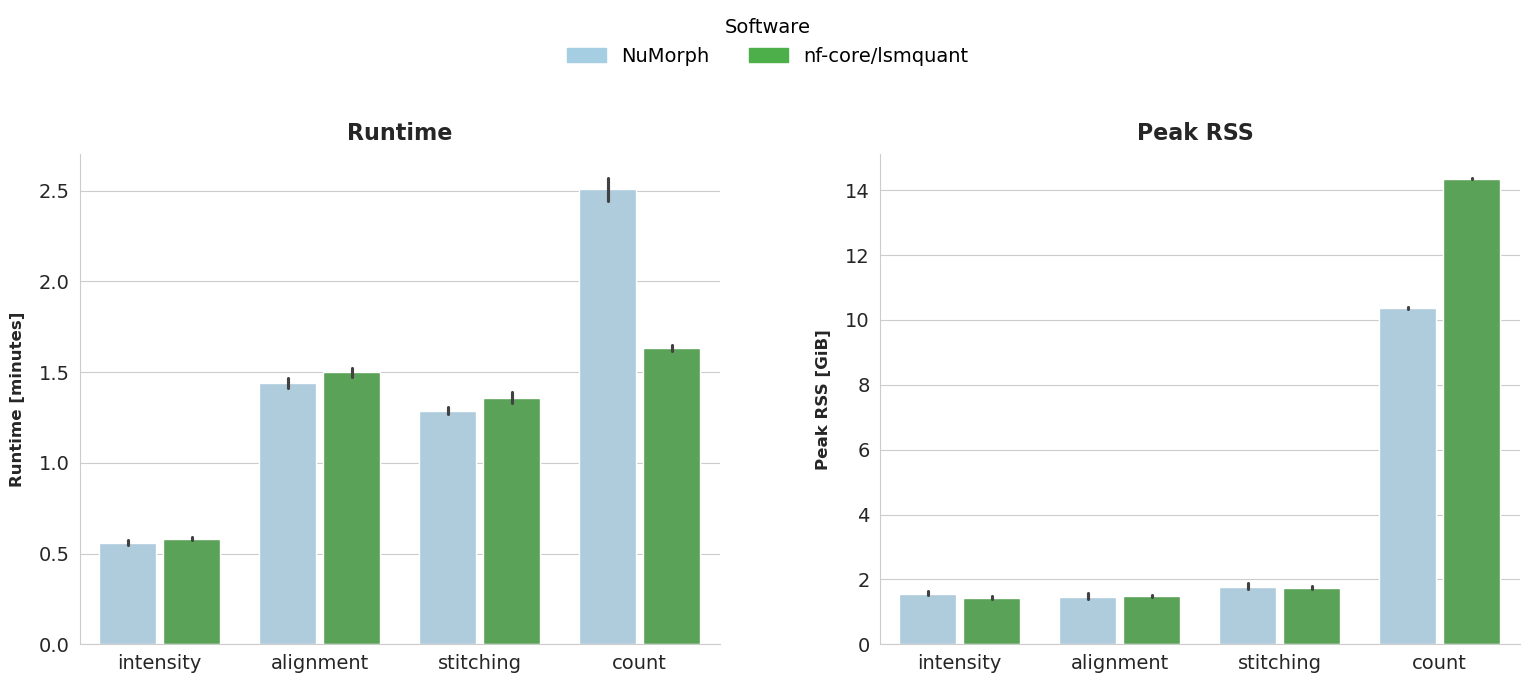

In [89]:
processes = benchmark_df['process'].unique()
metrics = [
    ("realtime", "Runtime", "Runtime [minutes]"),
    ("peak_rss",  "Peak RSS ", "Peak RSS [GiB]"),
]
 
fig = plt.figure(figsize=(16, 7))
 
# Use the FULL figure width for the 2 bar plots side by side
# (previously gs_outer[0] only used the left half, leaving the right half empty)
gs_bar = GridSpec(
    1, 2, figure=fig,
    wspace=0.25,            # space between the two subplots
    top=0.82, bottom=0.12, left=0.07, right=0.97
)
 
with sns.axes_style("whitegrid"):
    bar_axes = [fig.add_subplot(gs_bar[0, i]) for i in range(2)]
 
    for ax, (y_col, y_label, y_units) in zip(bar_axes, metrics):
        sns.barplot(
            data=benchmark_df, x='process', y=y_col,
            hue='software', legend=False,
            palette=palette, ax=ax, gap=0.1, errorbar="pi" # show a 95% interval, ranging from the 2.5 to the 97.5 percentiles(seaborn - documentation)
        )
        ax.set_title(y_label, fontsize=16, fontweight="bold", pad=10)
        ax.set_xlabel("")
        ax.set_ylabel(y_units, fontsize=12, fontweight="bold", labelpad=10)
        ax.yaxis.set_tick_params(labelsize=14)
 
        # Rotate x-tick labels slightly so they don't overlap each other
        ax.set_xticklabels(processes, fontsize=14, rotation=0)
        ax.tick_params(axis='x', labelsize=14)
 
        ax.spines[["top", "right"]].set_visible(False)
 
# ── Single shared legend at the top ─────────────────────────────────────────
handles = [mpatches.Patch(color=palette[s], label=s)
           for s in benchmark_df['software'].unique()]
fig.legend(
    handles=handles,
    title="Software",
    loc="upper center",
    ncol=len(handles),
    fontsize=14,
    title_fontsize=14,
    bbox_to_anchor=(0.5, 1.04),
    frameon=False,
)

# Save figure
plt.savefig("./Figures/Figure_5_resource_usage_test_dataset.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()


#### combined bar plot and box plot 

/tmp/ipykernel_2609786/2156262793.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(processes, fontsize=16)
/tmp/ipykernel_2609786/2156262793.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(processes, fontsize=16)


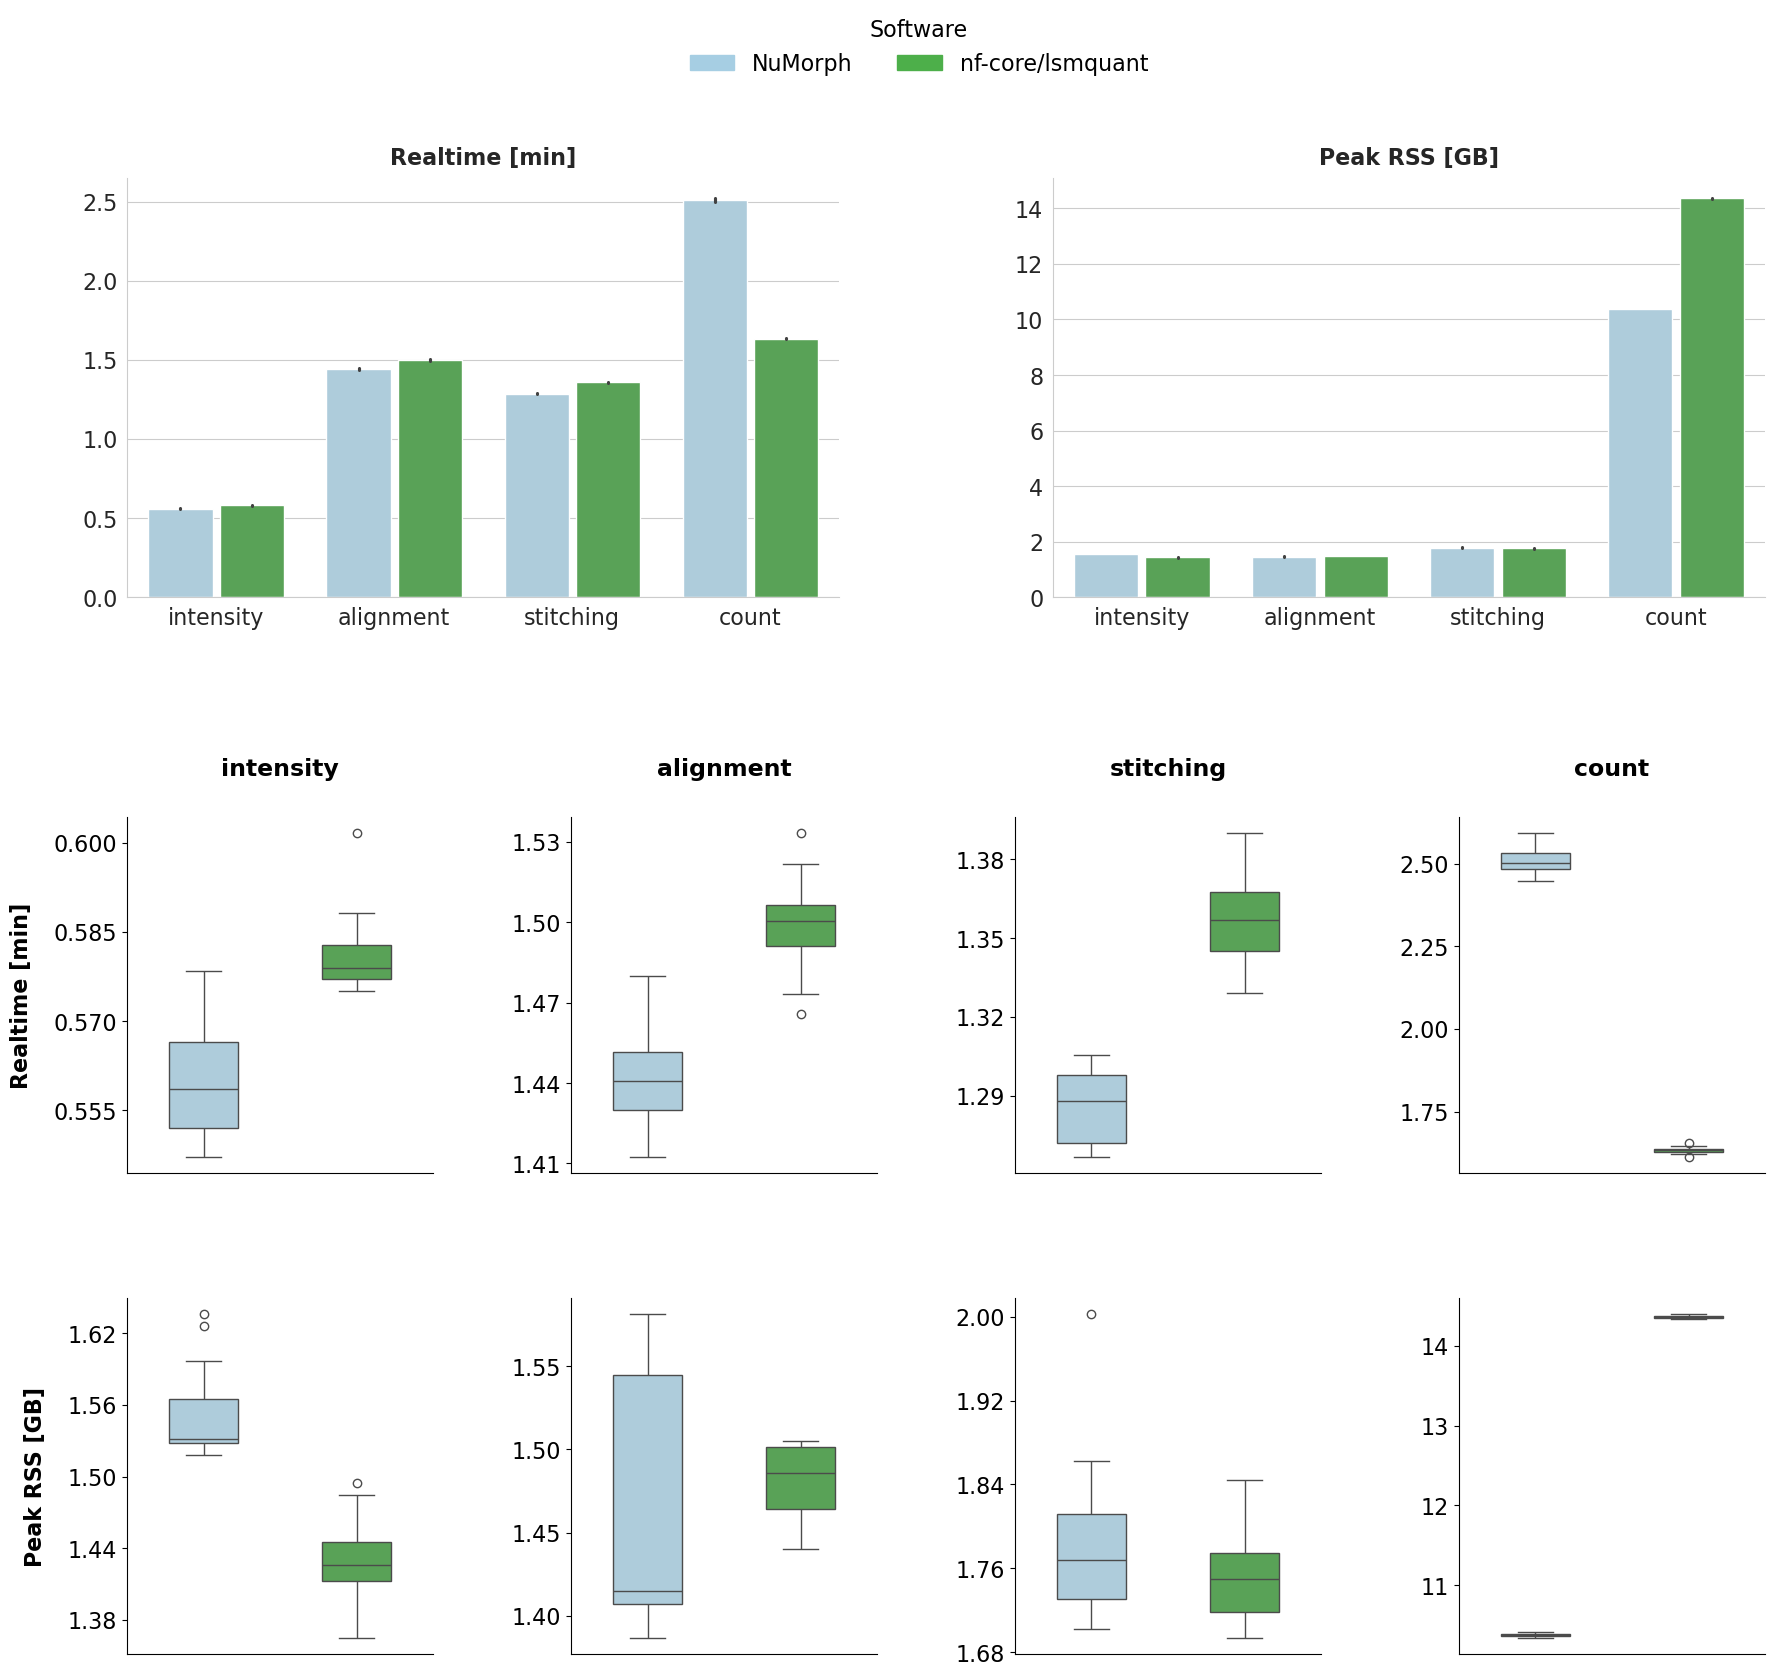

In [20]:
processes = benchmark_df['process'].unique()
metrics = [
    ("realtime", "Realtime [min]"),
    ("peak_rss",  "Peak RSS [GB]"),
]

fig = plt.figure(figsize=(18, 18))

gs_outer = GridSpec(2, 1, figure=fig, hspace=0.35,
                    top=0.88, bottom=0.06, left=0.06, right=0.97, height_ratios=[1, 2])

gs_bar   = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_outer[0], wspace=0.3)
gs_box   = GridSpecFromSubplotSpec(2, 4, subplot_spec=gs_outer[1],
                                   wspace=0.45, hspace=0.35)

# ── Row 1: 2 bar plots ──────────────────────────────────────────────────────
with sns.axes_style("whitegrid"):
    bar_axes = [fig.add_subplot(gs_bar[0, i]) for i in range(2)]

    for ax, (y_col, y_label) in zip(bar_axes, metrics):

        sns.barplot(
            data=benchmark_df, x='process', y=y_col,
            hue='software', legend=False,
            palette=palette, ax=ax, gap=0.1
        )
        ax.set_title(y_label, fontsize=16, fontweight="bold", pad=10)
        ax.set_xlabel("")
        ax.set_ylabel("")
        #ax.set_ylabel(y_label, fontsize=12, fontweight="bold", labelpad=10)
        ax.yaxis.set_tick_params(labelsize=16)
        ax.set_xticklabels(processes, fontsize=16)
        ax.spines[["top", "right"]].set_visible(False)

# ── Row 2 : 2×4 boxplot grid ─────────────────────────────────────────────
# Box plot axes inside gs_box

#with sns.axes_style("whitegrid"):
box_axes = [[fig.add_subplot(gs_box[row, col])
            for col in range(4)]
            for row in range(2)]

for row, (y_col, y_label) in enumerate(metrics):
    for col, process in enumerate(processes):
        ax = box_axes[row][col]
        df_sub = benchmark_df[benchmark_df['process'] == process]

        sns.boxplot(
            data=df_sub, x='software', y=y_col,
            hue='software', ax=ax,
            palette=palette, legend=False,
            gap=0.1, width=0.5,
        )
        ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=5))

        # Column title only on top row
        if row == 0:
            ax.set_title(process, fontsize=17, fontweight="bold", pad=30)

        # Y-axis label only on leftmost column
        ax.set_ylabel(y_label if col == 0 else "",
                    fontsize=16, fontweight="bold", labelpad=15)
        ax.set_xlabel("")
        ax.set_xticks([])
        ax.tick_params(axis='y', labelsize=16)
        ax.spines[["top", "right"]].set_visible(False)

# ── Single shared legend at the top ─────────────────────────────────────────
handles = [mpatches.Patch(color=palette[s], label=s)
           for s in benchmark_df['software'].unique()]
fig.legend(
    handles=handles,
    title="Software",
    loc="upper center",
    ncol=len(handles),
    fontsize=16,
    title_fontsize=16,
    bbox_to_anchor=(0.5, 0.98),
    frameon=False,
)

# Save figurer
plt.savefig("resource_usage_testdataset.png", dpi=300, bbox_inches="tight",
            facecolor="white")

plt.show()

#### Boxplots all monitured resources

/tmp/ipykernel_2609786/3925859933.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


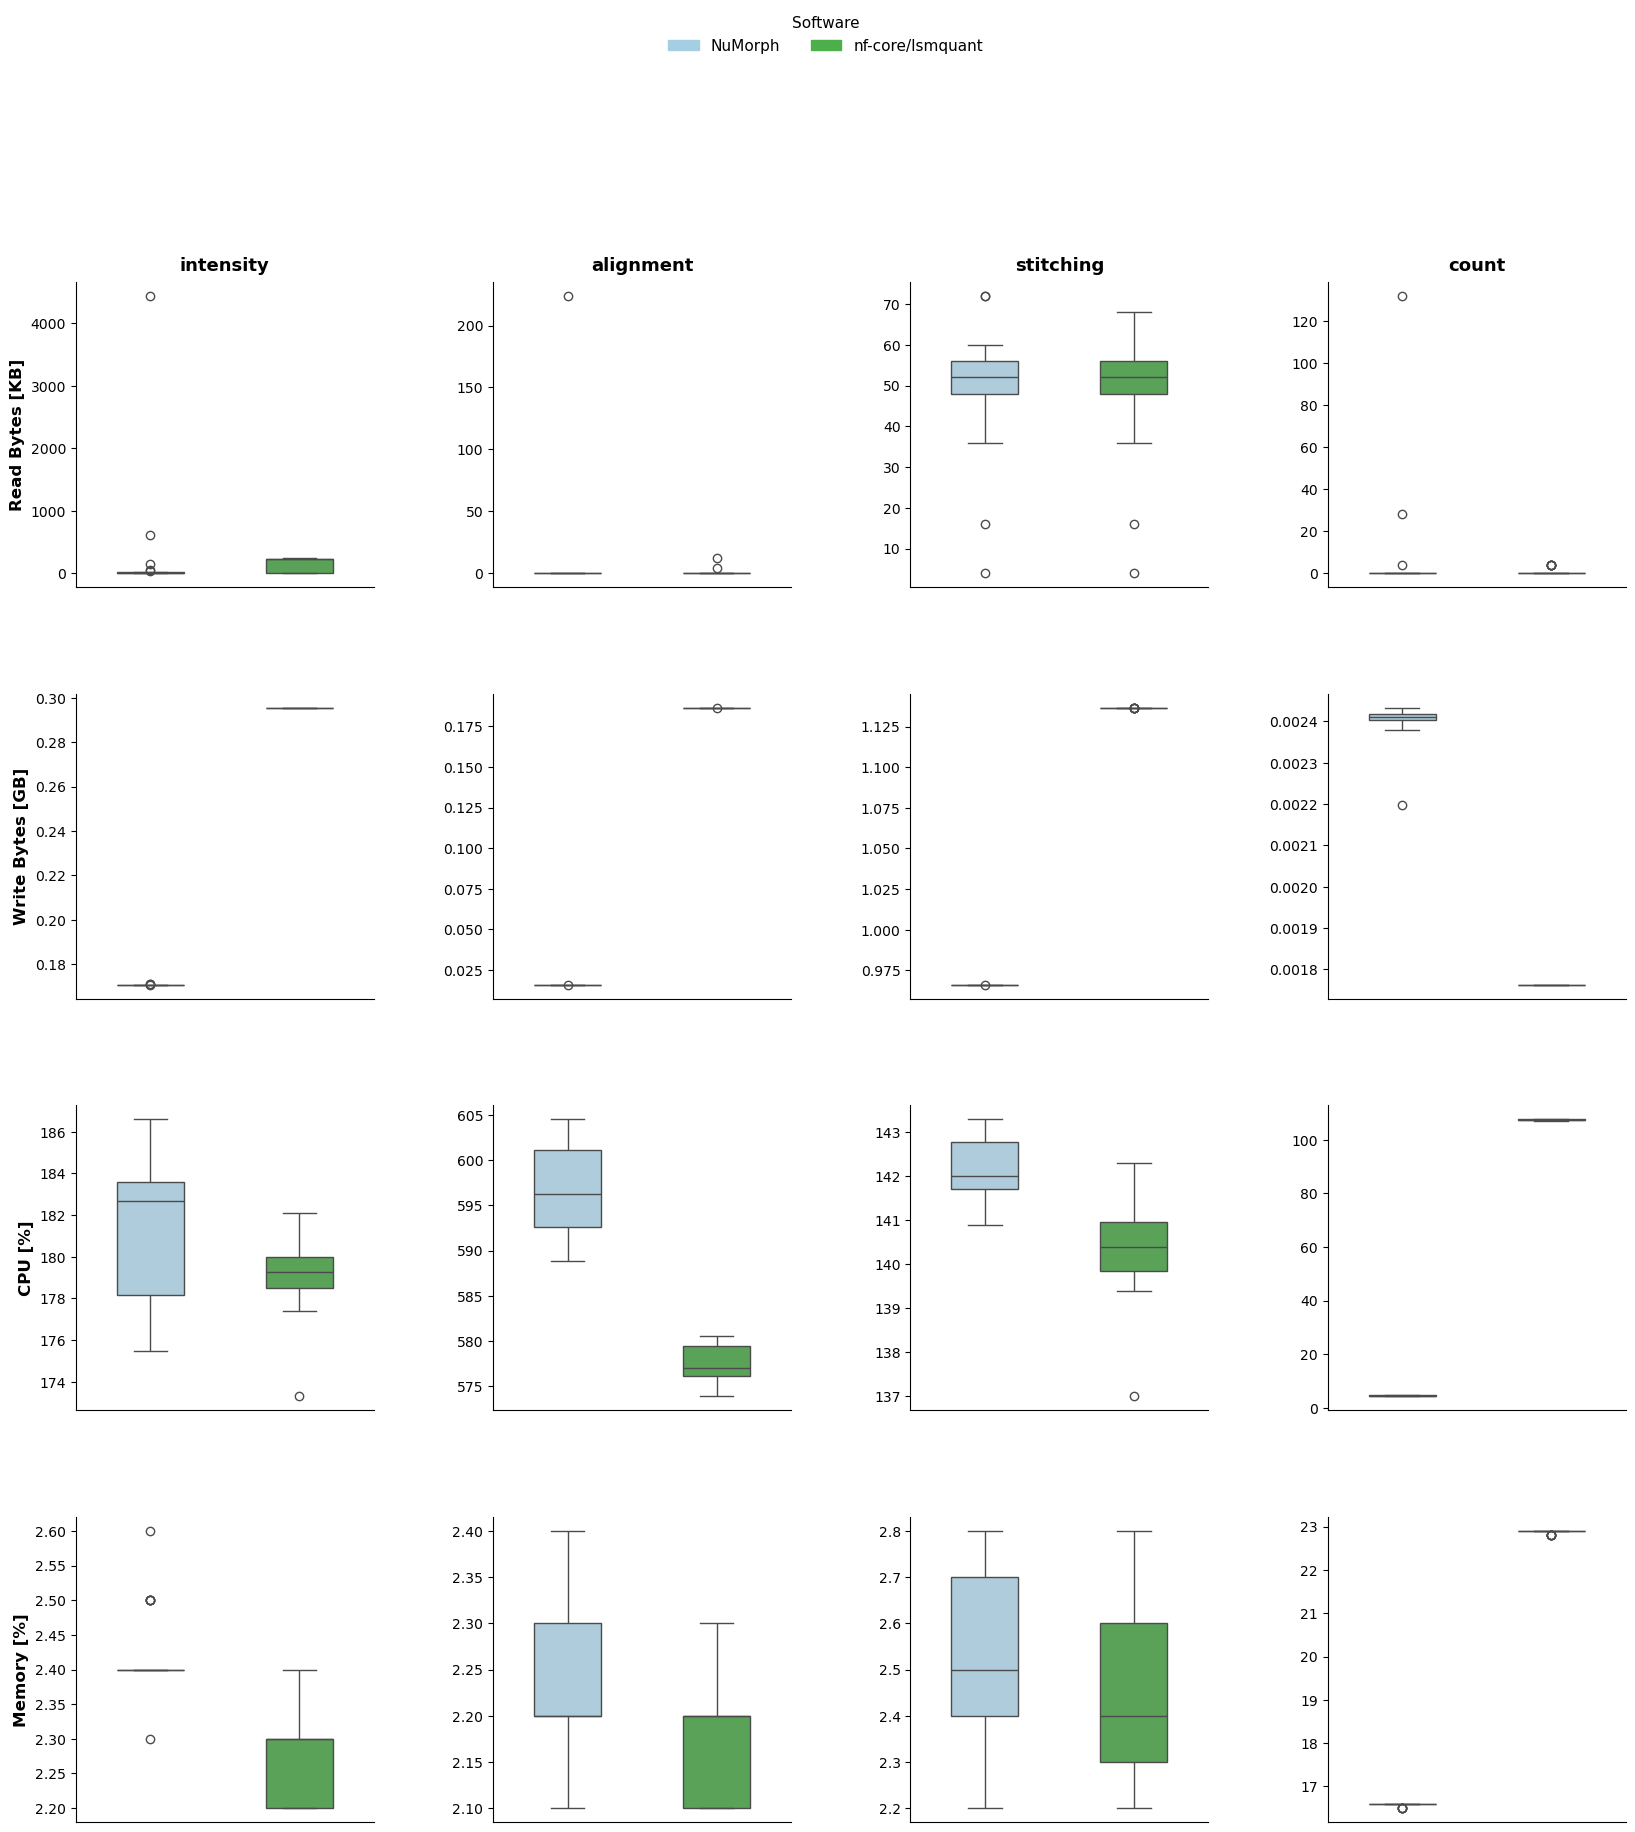

In [21]:

processes = benchmark_df['process'].unique()  # ['intensity', 'alignment', 'stitching', 'count']
metrics = [
    ("read_bytes",  "Read Bytes [KB]"),
    ("write_bytes",  "Write Bytes [GB]"),
    ("pcpu",  "CPU [%]"),
    ("pmem",  "Memory [%]"),
]

fig, axes = plt.subplots(
    nrows=4, ncols=4,
    figsize=(20, 20),
    gridspec_kw={"hspace": 0.35, "wspace": 0.4}
)

for row, (y_col, y_label) in enumerate(metrics):
    for col, process in enumerate(processes):
        ax = axes[row, col]

        df_sub = benchmark_df[benchmark_df['process'] == process]

        sns.boxplot(
            data=df_sub,
            x='software',
            y=y_col,
            hue='software',
            ax=ax,
            palette=palette,
            legend=False,
            gap=0.1,
            width=0.5,
        )

        # Title only on top row
        if row == 0:
            ax.set_title(process, fontsize=13, fontweight="bold", pad=8)

        # Y-axis label only on leftmost column
        if col == 0:
            ax.set_ylabel(y_label, fontsize=12, fontweight="bold")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")
        ax.set_xticks([])  # remove x tick labels — legend handles software identity

        ax.tick_params(axis='y', labelsize=10)
        ax.spines[["top", "right"]].set_visible(False)

# Single shared legend — pull handles from any axis
handles = [
    plt.matplotlib.patches.Patch(color=palette[s], label=s)
    for s in benchmark_df['software'].unique()
]
fig.legend(
    handles=handles,
    title="Software",
    loc="upper center",
    ncol=len(handles),
    fontsize=11,
    title_fontsize=11,
    bbox_to_anchor=(0.5, 1.02),
    frameon=False,
)

fig.suptitle("")  # clear any auto title
plt.tight_layout()
plt.show()

## Scaling results

helper function to convert durations from strings to floats of minutes

In [ ]:
# function 
# convert the runtimes from strings to floats in minutes. The durations are in the format "HH:MM:SS" or "MM:SS" or "SS".
def duration_to_minutes(duration_str):
    total_minutes = 0
    parts = duration_str.split(' ')
    for part in parts:
        if 'h' in part:
            hours = int(part.replace('h', ''))
        else:
            hours = 0
        if 'm' in part:
            minutes = int(part.replace('m', ''))
        else:
            minutes = 0
        if 's' in part:
            seconds = int(part.replace('s', ''))
        else:
            seconds = 0      
        total_minutes += (hours * 60) + minutes + (seconds / 60)
    return total_minutes

### Aggregate results from scaling experiments

In [63]:
# extract durations from nf-core/lsmquant execution reports 
lsmquant_scaling_base_path = "/mnt/ssd/performance_benchmark/scaling/nextflow"
# empty dictionary to store runtime for each number of samples
lsmquant_scaling_data = {}

In [64]:

# iterate over the subdirs n_sample_[number]
for subdir in os.listdir(lsmquant_scaling_base_path):
    subdir_path = os.path.join(lsmquant_scaling_base_path, subdir)
    print(subdir_path)
    # find file in subdir with the pattern  pipeline_info/execution_report*.html
    report_file_pattern = os.path.join(subdir_path, "pipeline_info/execution_report*.html")
    report_files = glob.glob(report_file_pattern)
    if report_files:
        report_file = report_files[0]
        # parse the html file with BeautifulSoup
        with open(report_file, 'r') as f:
            soup = BeautifulSoup(f, 'html.parser')
            # find the table with id="processes"
            dt = soup.find("dt", string="Run times")
            if dt:
                dd = dt.find_next("dd")
                duration = dd.find("strong").get_text(strip=True)
                duration_min = duration_to_minutes(duration)
                lsmquant_scaling_data[subdir] = duration_min




print(lsmquant_scaling_data)

lsmquant_scaling_data = {
    int(key.split("_")[2]): value
    for key, value in lsmquant_scaling_data.items()
}
print(lsmquant_scaling_data)


/mnt/ssd/performance_benchmark/scaling/nextflow/n_sample_8
/mnt/ssd/performance_benchmark/scaling/nextflow/n_sample_7
/mnt/ssd/performance_benchmark/scaling/nextflow/n_sample_2
/mnt/ssd/performance_benchmark/scaling/nextflow/n_sample_1
/mnt/ssd/performance_benchmark/scaling/nextflow/n_sample_6
/mnt/ssd/performance_benchmark/scaling/nextflow/n_sample_4
/mnt/ssd/performance_benchmark/scaling/nextflow/n_sample_10
/mnt/ssd/performance_benchmark/scaling/nextflow/n_sample_5
/mnt/ssd/performance_benchmark/scaling/nextflow/n_sample_9
/mnt/ssd/performance_benchmark/scaling/nextflow/n_sample_3
{'n_sample_8': 29.6, 'n_sample_7': 26.316666666666666, 'n_sample_2': 8.866666666666667, 'n_sample_1': 6.066666666666666, 'n_sample_6': 22.766666666666666, 'n_sample_4': 15.816666666666666, 'n_sample_10': 36.61666666666667, 'n_sample_5': 19.416666666666668, 'n_sample_9': 33.18333333333333, 'n_sample_3': 12.633333333333333}
{8: 29.6, 7: 26.316666666666666, 2: 8.866666666666667, 1: 6.066666666666666, 6: 22.76

In [68]:
# get numorph runtimes 
numorph_scaling_base_path = "/mnt/ssd/performance_benchmark/scaling/"
# empty dictionary to store runtime for each number of samples
numorph_scaling_data = {}

In [69]:
# iterate over n*_samples directories
for n_sample_dir in os.listdir(numorph_scaling_base_path):
    n_sample_dir_path = os.path.join(numorph_scaling_base_path, n_sample_dir)
    if os.path.isdir(n_sample_dir_path) and n_sample_dir.endswith("_samples"):
        # total duration for processing all n samples in the directory
        total_duration = 0
        # iterate over the sample subdirs and find the trace files for each process and extract the realtime value
        for subdir in os.listdir(n_sample_dir_path):
            subdir_path = os.path.join(n_sample_dir_path, subdir)
            # get the trace files for each process and extract the realtime value
            if os.path.isdir(subdir_path) and subdir.startswith("sample"):
                align_trace_file_pattern = os.path.join(subdir_path, "align/matlab_trace.log")
                intensity_trace_file_pattern = os.path.join(subdir_path, "intensity/matlab_trace.log")
                stitch_trace_file_pattern = os.path.join(subdir_path, "stitch/matlab_trace.log")
                count_trace_file_pattern = os.path.join(subdir_path, "process_count/matlab_trace.log")
                trace_file_patterns = [align_trace_file_pattern, intensity_trace_file_pattern, stitch_trace_file_pattern, count_trace_file_pattern]
                # get the total duration by summing the realtime values from all trace files per sample
                duration_per_sample = 0
                for trace_file in trace_file_patterns:
                    if os.path.exists(trace_file):
                        with open(trace_file, 'r') as f:
                            for line in f:
                                if 'realtime' in line:
                                    realtime_value = int(line.split('realtime=')[1].strip())
                                    # convert to minutes
                                    realtime_value_min = realtime_value / 60000
                                    duration_per_sample += realtime_value_min

                # add the per_sample duration to the total duration for the n samples
                total_duration += duration_per_sample
        numorph_scaling_data[n_sample_dir] = total_duration
                

print(numorph_scaling_data)
numorph_scaling_data = {
    int(key.split("_")[0].split("n")[1]): value
    for key, value in numorph_scaling_data.items()
}
print(numorph_scaling_data)

{'n03_samples': 17.382, 'n04_samples': 23.244766666666663, 'n02_samples': 11.620999999999999, 'n07_samples': 40.68921666666666, 'n01_samples': 5.803933333333333, 'n05_samples': 28.931933333333337, 'n10_samples': 57.84433333333334, 'n08_samples': 46.24663333333333, 'n09_samples': 51.96905, 'n06_samples': 34.84955}
{3: 17.382, 4: 23.244766666666663, 2: 11.620999999999999, 7: 40.68921666666666, 1: 5.803933333333333, 5: 28.931933333333337, 10: 57.84433333333334, 8: 46.24663333333333, 9: 51.96905, 6: 34.84955}


### Manuscript Figure 6

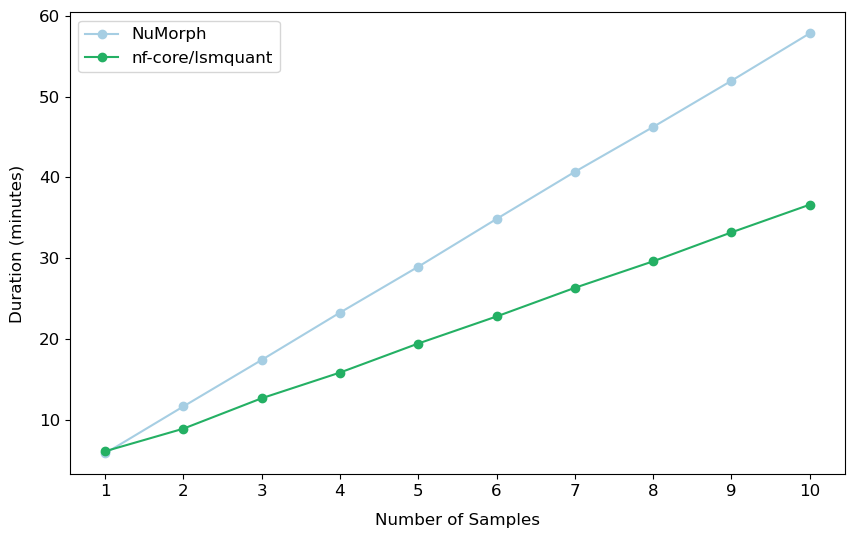

In [90]:
# plot the scaling results: x axis is n_samples and y axis is the duration in minutesfor numorph and nf-core/lsmquant
# show all x axis ticks
plt.figure(figsize=(10, 6))

numorph_sorted = sorted(numorph_scaling_data.items())
lsmquant_sorted = sorted(lsmquant_scaling_data.items())

numorph_x, numorph_y = zip(*numorph_sorted)
lsmquant_x, lsmquant_y = zip(*lsmquant_sorted)

plt.plot(numorph_x, numorph_y, marker='o', label='NuMorph', color="#a6cee3")
plt.plot(lsmquant_x, lsmquant_y, marker='o', label='nf-core/lsmquant', color="#24B064")

plt.xlabel('Number of Samples', fontsize=12, labelpad=10)
plt.xticks(numorph_x, fontsize=12)  # show all x-axis ticks, now in correct sorted order
plt.yticks(fontsize=12)
plt.ylabel('Duration (minutes)', fontsize=12, labelpad=10)
plt.legend(fontsize=12)
plt.savefig("./Figures/Figure_6_scaling.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

#### plot FAIRsoft score


In [23]:
FAIR_score = pd.DataFrame({
    'software': ['NuMorph', 'nf-core/lsmquant'],
    'Findability': [66, 100],
    'Accessability': [85, 85],
    'Interoperability': [82.7, 87.7],
    'Reusability': [70, 100]
})

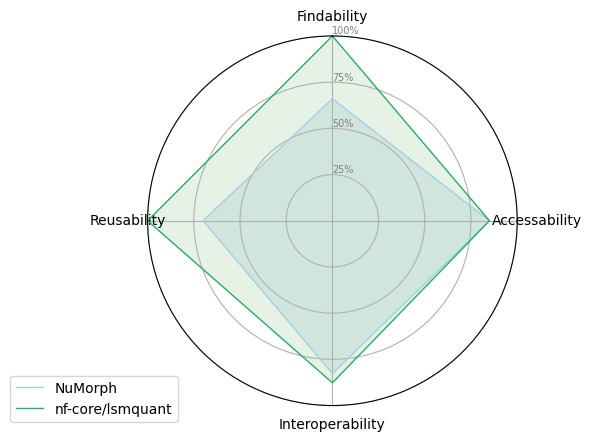

In [24]:
# ------- PART 1: Create background
 
# number of variable
categories=list(FAIR_score)[1:]
N = len(categories)
 
# What will be the angle of each axis in the plot? (we divide the plot / number of variable)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]
 
# Initialise the spider plot
ax = plt.subplot(111, polar=True)
 
# If you want the first axis to be on top:
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
 
# Draw one axe per variable + add labels
plt.xticks(angles[:-1], categories)
 
# Draw ylabels
ax.set_rlabel_position(0)
plt.yticks([25,50,75,100], ["25%","50%","75%", "100%"], color="grey", size=7)
plt.ylim(0,100)
 

# ------- PART 2: Add plots
 
# Plot each individual = each line of the data
# I don't make a loop, because plotting more than 3 groups makes the chart unreadable
 
# Ind1
values=FAIR_score.loc[0].drop('software').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=1, linestyle='solid', label="NuMorph", color="#a6cee3")
ax.fill(angles, values, 'o', alpha=0.1)
 
# Ind2
values=FAIR_score.loc[1].drop('software').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=1, linestyle='solid', label="nf-core/lsmquant", color="#24B064")
ax.fill(angles, values, 'g', alpha=0.1)
 
# Add legend
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

# Show the graph
plt.show()